## Environment setup and dataset extraction

The first cells install any missing package, inspect the downloaded archives, and extract the
LEVIR-CD dataset into the working directory so the rest of the notebook can access the train,
validation, and test splits.

In [1]:
!pip -q install gdown

# Download the official LEVIR-CD Google Drive folder
# Source folder id: 1dLuzldMRmbBNKPpUkX8Z53hi6NHLrWim
!gdown --folder 1dLuzldMRmbBNKPpUkX8Z53hi6NHLrWim -O levir_cd_raw

!ls -lah levir_cd_raw


Retrieving folder contents
Retrieving folder 1C2B5_wiZVUt-PWHn14H9lSKF5sA6jowR BIT_LEVIR
Processing file 1IVdF5a3e1_7DiSndtMkhpZuCSgDLLFcg best_ckpt.pt
Retrieving folder 1QZOYP-N2Nr27aDG38zTVJMunfzmrseLv PAM-pretrain
Processing file 196bR8LdSfVawnSOVmM_YPW25UetucUYX pam_net_A.pth
Processing file 1QOjoa-YFvHOgCLXaxvZUlrlidihpmbWU pam_net_F.pth
Processing file 1jj3qJD_grJlgIhUWO09zibRGJe0R4Tn0 test.zip
Processing file 18GuoCuBn48oZKAlEo-LrNwABrFhVALU- train.zip
Processing file 1BqSt4ueO7XAyQ_84mUjswUSJt13ZBuzG val.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1IVdF5a3e1_7DiSndtMkhpZuCSgDLLFcg
To: /content/levir_cd_raw/BIT_LEVIR/best_ckpt.pt
100% 60.0M/60.0M [00:00<00:00, 92.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=196bR8LdSfVawnSOVmM_YPW25UetucUYX
To: /content/levir_cd_raw/PAM-pretrain/pam_net_A.pth
100% 162k/162k [00:00<00:00, 4.45MB/s]
Downloading...
From

In [2]:
!find levir_cd_raw -maxdepth 2 -type f \( -name "*.zip" -o -name "*.rar" -o -name "*.7z" \) -print


levir_cd_raw/test.zip
levir_cd_raw/train.zip
levir_cd_raw/val.zip


In [3]:
!unzip -q levir_cd_raw/train.zip -d levir_cd
!unzip -q levir_cd_raw/val.zip   -d levir_cd
!unzip -q levir_cd_raw/test.zip  -d levir_cd
!ls -lah levir_cd


total 72K
drwxr-xr-x 5 root root 4.0K Mar  8 14:28 .
drwxr-xr-x 1 root root 4.0K Mar  8 14:28 ..
drwxr-xr-x 2 root root  20K Mar  8 14:28 A
drwxr-xr-x 2 root root  20K Mar  8 14:28 B
drwxr-xr-x 2 root root  20K Mar  8 14:28 label


In [4]:
# Remove the mixed folder
!rm -rf levir_cd

# Recreate split directories
!mkdir -p levir_cd/train levir_cd/val levir_cd/test

# Unzip each split into its own folder
!unzip -q levir_cd_raw/train.zip -d levir_cd/train
!unzip -q levir_cd_raw/val.zip   -d levir_cd/val
!unzip -q levir_cd_raw/test.zip  -d levir_cd/test

# Inspect final structure
!ls -lah levir_cd


total 20K
drwxr-xr-x 5 root root 4.0K Mar  8 14:28 .
drwxr-xr-x 1 root root 4.0K Mar  8 14:28 ..
drwxr-xr-x 5 root root 4.0K Mar  8 14:29 test
drwxr-xr-x 5 root root 4.0K Mar  8 14:29 train
drwxr-xr-x 5 root root 4.0K Mar  8 14:29 val


## Basic utilities and path helpers

Here we import the main Python libraries and define helper functions used throughout the notebook
for listing files, loading samples, and preparing the dataset splits.

In [5]:
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2

DATA_ROOT = "levir_cd"

def list_split(split):
    a = sorted(glob(os.path.join(DATA_ROOT, split, "A", "*")))
    b = sorted(glob(os.path.join(DATA_ROOT, split, "B", "*")))
    m = sorted(glob(os.path.join(DATA_ROOT, split, "label", "*")))
    assert len(a) == len(b) == len(m), f"Count mismatch in {split}: {len(a)}, {len(b)}, {len(m)}"
    return a, b, m

trainA, trainB, trainM = list_split("train")
valA, valB, valM = list_split("val")
testA, testB, testM = list_split("test")

print("Counts:",
      "train", len(trainA),
      "val", len(valA),
      "test", len(testA))
print("Example file:", os.path.basename(trainA[0]))


Counts: train 445 val 64 test 128
Example file: train_1.png


# Detecting Object Changes in Images Using Deep Learning

## Project overview
This notebook presents a deep learning pipeline for **satellite image change detection**.  
The task is to compare two images of the same area captured at different times and predict a **binary mask**
showing where meaningful structural changes occurred.

## Main stages
1. Dataset preparation and inspection  
2. Exploratory data analysis  
3. `tf.data` input pipeline construction  
4. Siamese U-Net model definition  
5. Training and validation  
6. Test-time prediction and evaluation

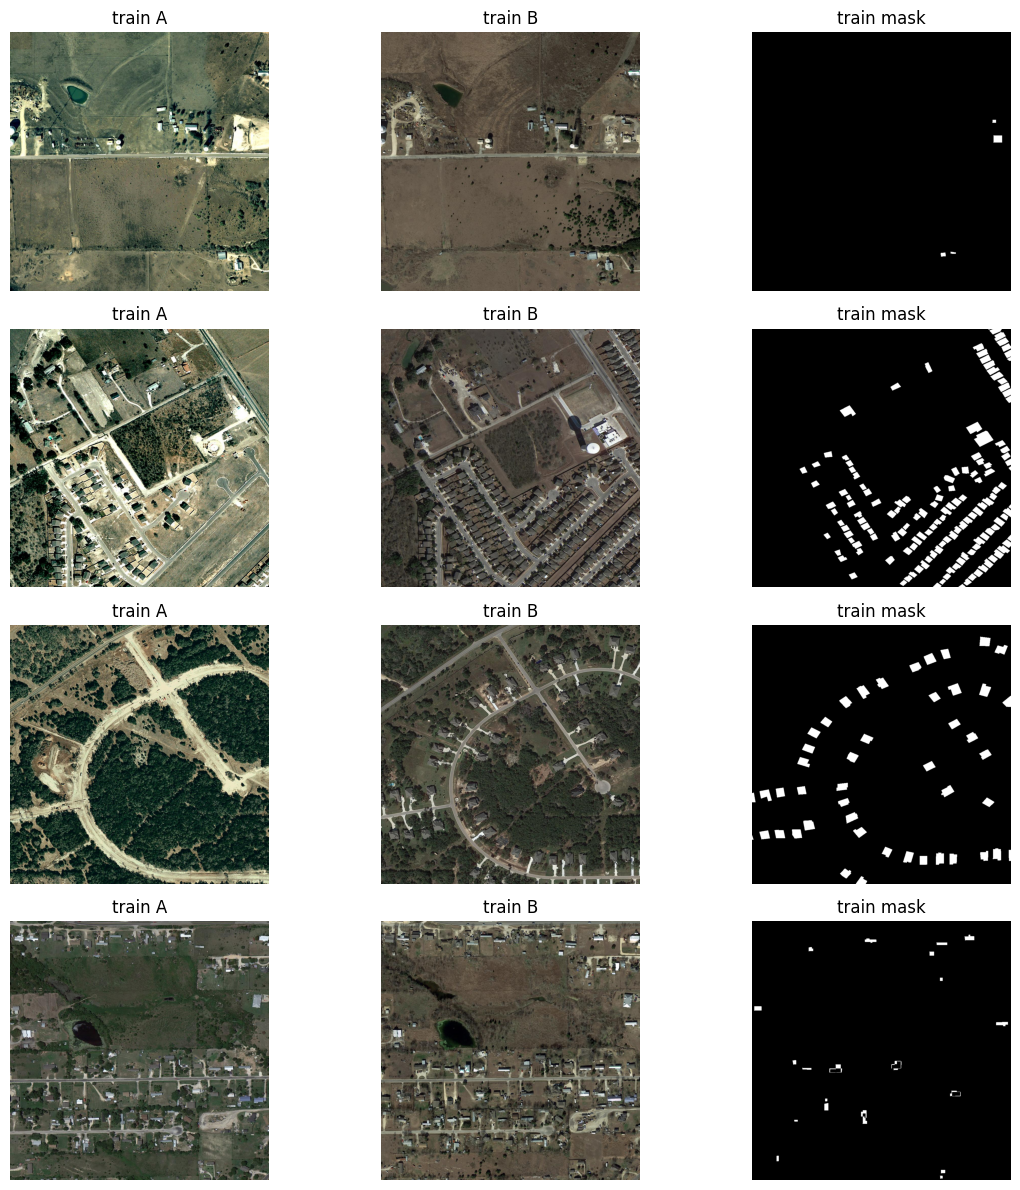

In [6]:
import random

def show_samples(split="train", n=4, seed=42):
    random.seed(seed)
    A, B, M = list_split(split)
    idxs = random.sample(range(len(A)), n)

    plt.figure(figsize=(12, 3*n))
    for i, idx in enumerate(idxs):
        imgA = cv2.cvtColor(cv2.imread(A[idx]), cv2.COLOR_BGR2RGB)
        imgB = cv2.cvtColor(cv2.imread(B[idx]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(M[idx], cv2.IMREAD_GRAYSCALE)

        plt.subplot(n, 3, 3*i+1); plt.imshow(imgA); plt.title(f"{split} A"); plt.axis("off")
        plt.subplot(n, 3, 3*i+2); plt.imshow(imgB); plt.title(f"{split} B"); plt.axis("off")
        plt.subplot(n, 3, 3*i+3); plt.imshow(mask, cmap="gray"); plt.title(f"{split} mask"); plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples("train", n=4)


## Exploratory Data Analysis 1 — Class imbalance

Before training the model, it is important to understand how many pixels correspond to **changed** regions
versus **unchanged** regions. In change detection datasets, the positive class is often much smaller, which can
make the learning problem more difficult and can make accuracy alone misleading.

train: sampled 300 masks
Mean changed ratio: 0.04406510666012764
Std: 0.04758469760417938
Min / Max: 0.0 0.21807003021240234


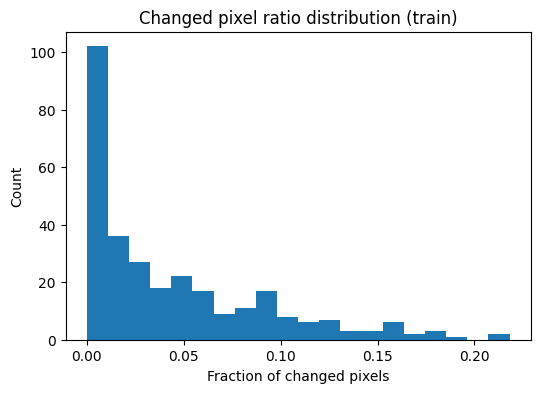

In [7]:
def changed_ratio(split="train", sample_k=200, seed=0):
    np.random.seed(seed)
    _, _, M = list_split(split)
    k = min(sample_k, len(M))
    idxs = np.random.choice(len(M), size=k, replace=False)

    ratios = []
    for idx in idxs:
        mask = cv2.imread(M[idx], cv2.IMREAD_GRAYSCALE)
        m = (mask > 0).astype(np.float32)  # binarize (0/255 -> 0/1)
        ratios.append(m.mean())

    ratios = np.array(ratios)
    print(f"{split}: sampled {k} masks")
    print("Mean changed ratio:", float(ratios.mean()))
    print("Std:", float(ratios.std()))
    print("Min / Max:", float(ratios.min()), float(ratios.max()))

    plt.figure(figsize=(6,4))
    plt.hist(ratios, bins=20)
    plt.title(f"Changed pixel ratio distribution ({split})")
    plt.xlabel("Fraction of changed pixels")
    plt.ylabel("Count")
    plt.show()

changed_ratio("train", sample_k=300)


## Input pipeline

The following cells build a `tf.data` pipeline for efficient loading, preprocessing, patch extraction,
augmentation, batching, and prefetching. This makes training faster and ensures that both temporal images
and their ground-truth mask stay spatially aligned.

### TensorFlow imports and decoding utilities

This section imports TensorFlow and defines helper functions for loading the two temporal images and the
corresponding binary mask.

In [8]:
import tensorflow as tf

PATCH = 256
BATCH = 8
AUTOTUNE = tf.data.AUTOTUNE

def decode_rgb(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return img

def decode_mask(path):
    mask = tf.io.read_file(path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.cast(mask > 0, tf.float32)
    return mask


### Patch extraction and augmentation

The model is trained on image patches rather than full-resolution satellite images.  
Patch-based training:
- reduces memory usage,
- increases the number of training samples,
- helps the model learn local spatial patterns.

Simple augmentations are also applied to improve generalization.

In [9]:
def random_crop_pair(imgA, imgB, mask, patch=PATCH):
    stacked = tf.concat([imgA, imgB, mask], axis=-1)
    crop = tf.image.random_crop(stacked, [patch, patch, 7])
    return (crop[..., :3], crop[..., 3:6]), crop[..., 6:7]

def augment_pair(inputs, mask):
    A, B = inputs

    if tf.random.uniform(()) > 0.5:
        A = tf.image.flip_left_right(A)
        B = tf.image.flip_left_right(B)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        A = tf.image.flip_up_down(A)
        B = tf.image.flip_up_down(B)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform((), 0, 4, dtype=tf.int32)
    A = tf.image.rot90(A, k)
    B = tf.image.rot90(B, k)
    mask = tf.image.rot90(mask, k)

    return (A, B), mask


### Dataset builder

This function assembles the full dataset pipeline for the training, validation, and test splits.

In [10]:
def build_dataset(split="train", training=True):
    A_paths, B_paths, M_paths = list_split(split)
    ds = tf.data.Dataset.from_tensor_slices((A_paths, B_paths, M_paths))

    def load(a, b, m):
        imgA = decode_rgb(a)
        imgB = decode_rgb(b)
        mask = decode_mask(m)
        (A_crop, B_crop), M_crop = random_crop_pair(imgA, imgB, mask)
        if training:
            (A_crop, B_crop), M_crop = augment_pair((A_crop, B_crop), M_crop)
        return (A_crop, B_crop), M_crop

    if training:
        ds = ds.shuffle(1000)

    ds = ds.map(load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset("train", training=True)
val_ds = build_dataset("val", training=False)

print(train_ds)


<_PrefetchDataset element_spec=((TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None)), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>


### Visual check of one training batch

This step is to verify that:
- image pairs are loaded correctly,
- masks remain aligned after augmentation,
- patch extraction behaves as expected.

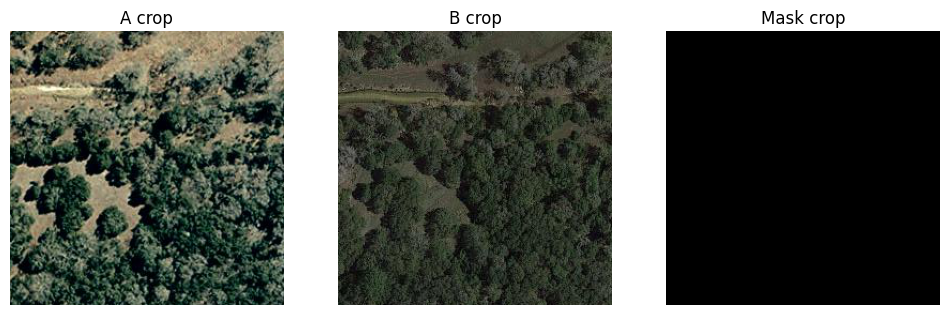

Batch shapes: (8, 256, 256, 3) (8, 256, 256, 3) (8, 256, 256, 1)


In [11]:
for (A, B), M in train_ds.take(1):
    A0 = A[0].numpy()
    B0 = B[0].numpy()
    M0 = M[0].numpy().squeeze()

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(A0); plt.title("A crop"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(B0); plt.title("B crop"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(M0, cmap="gray"); plt.title("Mask crop"); plt.axis("off")
    plt.show()

    print("Batch shapes:", A.shape, B.shape, M.shape)


# Part 2 — Model, Training, and Evaluation

Next step is to define the segmentation model, train it, and analyze
its performance using metrics for change detection.

## Evaluation metrics

Because the dataset is imbalanced, metrics such as **IoU** and **F1-score** are more informative than accuracy.
They better reflect how well the model detects relatively small changed regions.

In [12]:
import tensorflow as tf

def iou_score(y_true, y_pred, eps=1e-7):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    y_true = tf.cast(y_true > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1,2,3]) - inter
    return tf.reduce_mean((inter + eps) / (union + eps))

def f1_score(y_true, y_pred, eps=1e-7):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    y_true = tf.cast(y_true > 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    fp = tf.reduce_sum((1 - y_true) * y_pred, axis=[1,2,3])
    fn = tf.reduce_sum(y_true * (1 - y_pred), axis=[1,2,3])
    return tf.reduce_mean((2*tp + eps) / (2*tp + fp + fn + eps))


## Siamese U-Net architecture

The model uses two encoder branches with shared weights to process the two temporal images.
Their features are then compared, and a decoder reconstructs a pixelwise change map.

In [13]:
from tensorflow.keras import layers, models

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def encoder(x):
    c1 = conv_block(x, 32); p1 = layers.MaxPool2D()(c1)
    c2 = conv_block(p1, 64); p2 = layers.MaxPool2D()(c2)
    c3 = conv_block(p2, 128); p3 = layers.MaxPool2D()(c3)
    c4 = conv_block(p3, 256); p4 = layers.MaxPool2D()(c4)
    bn = conv_block(p4, 512)
    return (c1, c2, c3, c4, bn)

def up_block(x, skip, filters):
    x = layers.UpSampling2D()(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_siamese_unet(input_shape=(256,256,3)):
    inpA = layers.Input(shape=input_shape, name="A")
    inpB = layers.Input(shape=input_shape, name="B")

    # shared encoder
    shared = models.Model(inpA, encoder(inpA), name="shared_encoder")

    A1,A2,A3,A4,Abn = shared(inpA)
    B1,B2,B3,B4,Bbn = shared(inpB)

    # feature comparison (concat A, B, |A-B|)
    S1 = layers.Concatenate()([A1, B1, layers.Lambda(lambda t: tf.abs(t[0]-t[1]))([A1,B1])])
    S2 = layers.Concatenate()([A2, B2, layers.Lambda(lambda t: tf.abs(t[0]-t[1]))([A2,B2])])
    S3 = layers.Concatenate()([A3, B3, layers.Lambda(lambda t: tf.abs(t[0]-t[1]))([A3,B3])])
    S4 = layers.Concatenate()([A4, B4, layers.Lambda(lambda t: tf.abs(t[0]-t[1]))([A4,B4])])
    Sbn = layers.Concatenate()([Abn, Bbn, layers.Lambda(lambda t: tf.abs(t[0]-t[1]))([Abn,Bbn])])

    # decoder
    x = up_block(Sbn, S4, 256)
    x = up_block(x,   S3, 128)
    x = up_block(x,   S2, 64)
    x = up_block(x,   S1, 32)

    out = layers.Conv2D(1, 1, activation="sigmoid", name="mask")(x)

    model = models.Model([inpA, inpB], out, name="siamese_unet")
    return model

model = build_siamese_unet((PATCH, PATCH, 3))
model.summary()


Model: "siamese_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ A (InputLayer)      │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ B (InputLayer)      │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_encoder      │ [(None, 256, 256, │  4,720,160 │ A[0][0], B[0][0]  │
│ (Functional)        │ 32), (None, 128,  │            │                   │
│                     │ 128, 64), (None,  │            │                   │
│                     │ 64, 64, 128),     │            │                   │
│                     │ (None, 32, 32,    │            │                   │
│                     │ 256), (None, 16,  │            │                   │
│                     │ 16, 512)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 16, 16,    │          0 │ shared_encoder[0… │
│                     │ 512)              │            │ shared_encoder[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 16, 16,    │          0 │ shared_encoder[0… │
│ (Concatenate)       │ 1536)             │            │ shared_encoder[1… │
│                     │                   │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 32, 32,    │          0 │ shared_encoder[0… │
│                     │ 256)              │            │ shared_encoder[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ concatenate_4[0]… │
│ (UpSampling2D)      │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ shared_encoder[0… │
│ (Concatenate)       │ 768)              │            │ shared_encoder[1… │
│                     │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 2304)             │            │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │  5,308,672 │ concatenate_5[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │    590,080 │ re_lu_10[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 11,784,449 (44.95 MB)

 Trainable params: 11,778,561 (44.93 MB)

 Non-trainable params: 5,888 (23.00 KB)

## Training configuration

This section compiles the model and defines the optimizer, callbacks, and training process.
Checkpointing and early stopping are used to avoid overfitting.

In [14]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[iou_score, f1_score]
)

ckpt_path = "best_siamese_unet.keras"

callbacks = [
    ModelCheckpoint(ckpt_path, monitor="val_iou_score", mode="max", save_best_only=True),
    EarlyStopping(monitor="val_iou_score", mode="max", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_iou_score", mode="max", factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)


Epoch 1/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - f1_score: 0.2190 - iou_score: 0.1980 - loss: 0.5228 - val_f1_score: 0.0789 - val_iou_score: 0.0744 - val_loss: 0.4880 - learning_rate: 0.0010
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 51s 887ms/step - f1_score: 0.4278 - iou_score: 0.4176 - loss: 0.2370 - val_f1_score: 0.4688 - val_iou_score: 0.4688 - val_loss: 0.3124 - learning_rate: 0.0010
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 40s 711ms/step - f1_score: 0.3877 - iou_score: 0.3401 - loss: 0.1800 - val_f1_score: 0.6094 - val_iou_score: 0.6094 - val_loss: 0.1721 - learning_rate: 0.0010
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 47s 833ms/step - f1_score: 0.4234 - iou_score: 0.3870 - loss: 0.1517 - val_f1_score: 0.6397 - val_iou_score: 0.6346 - val_loss: 0.1509 - learning_rate: 0.0010
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 38s 677ms/step - f1_score: 0.4970 - iou_score: 0.4547 - loss: 0.1351 - val_f1_score: 0.6216 - val_iou_score: 0.6164 - val_loss: 0.1183 - learning_rate: 0.0010
Epoch 6/25
56/56 

## Training curves

The plots below show how the model evolves during training on the training and validation sets.
They help reveal possible overfitting or underfitting.

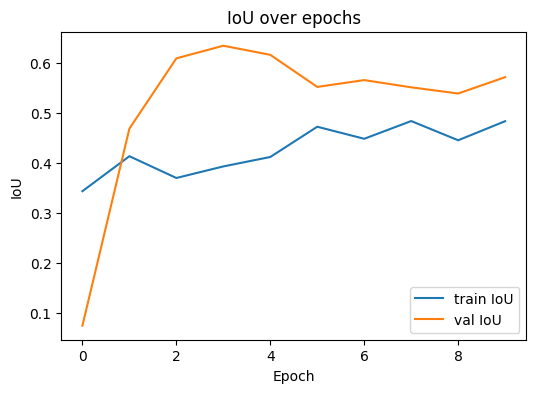

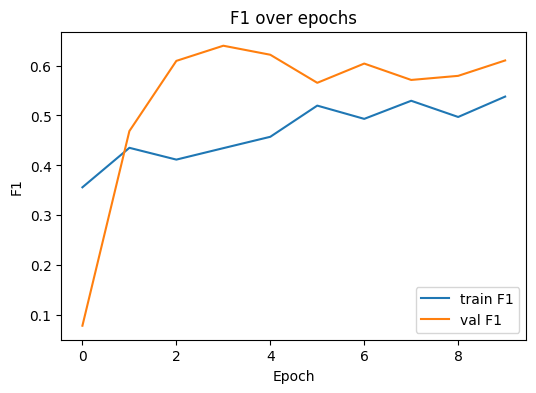

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history["iou_score"], label="train IoU")
plt.plot(history.history["val_iou_score"], label="val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("IoU over epochs")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["f1_score"], label="train F1")
plt.plot(history.history["val_f1_score"], label="val F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("F1 over epochs")
plt.legend()
plt.show()


### Qualitative prediction examples

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


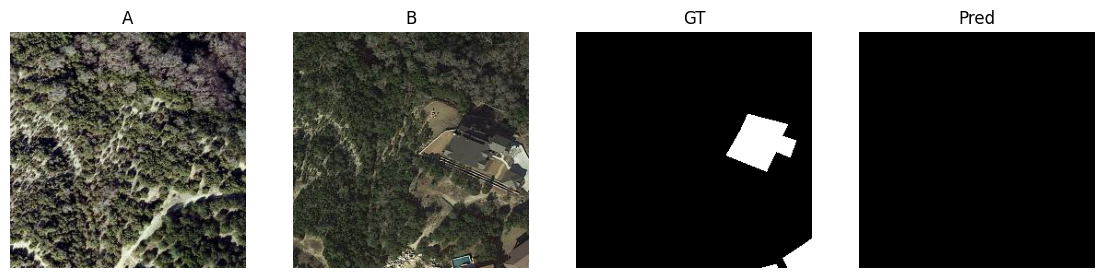

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def show_patch_with_change(dataset, threshold=0.001):
    for (A, B), M in dataset:
        # compute fraction of changed pixels per patch
        change_ratio = tf.reduce_mean(M, axis=[1,2,3]).numpy()
        idxs = np.where(change_ratio > threshold)[0]

        if len(idxs) > 0:
            i = idxs[0]
            A0 = A[i].numpy()
            B0 = B[i].numpy()
            M0 = M[i].numpy().squeeze()
            P0 = model.predict([A[i:i+1], B[i:i+1]])[0].squeeze()

            plt.figure(figsize=(14,4))
            plt.subplot(1,4,1); plt.imshow(A0); plt.title("A"); plt.axis("off")
            plt.subplot(1,4,2); plt.imshow(B0); plt.title("B"); plt.axis("off")
            plt.subplot(1,4,3); plt.imshow(M0, cmap="gray"); plt.title("GT"); plt.axis("off")
            plt.subplot(1,4,4); plt.imshow(P0 > 0.5, cmap="gray"); plt.title("Pred"); plt.axis("off")
            plt.show()
            return

    print("No patch with change found in this dataset.")

show_patch_with_change(val_ds)


# Part 3 — Inference, Visualization, and Final Evaluation

This final part loads the trained checkpoint, visualizes predictions, and computes quantitative results
on the evaluation data.

In [17]:
model.load_weights("best_siamese_unet.keras")
print("Loaded checkpoint weights.")


Loaded checkpoint weights.


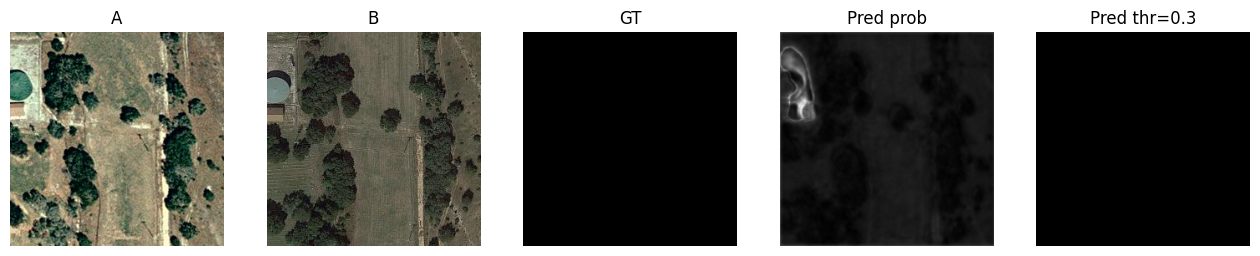

Pred prob stats: 0.01830221526324749 0.031093666329979897 0.16078156232833862
GT ratio: 0.0


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

(A, B), M = next(iter(val_ds))
P = model.predict([A, B], verbose=0)

i = 0
A0, B0 = A[i].numpy(), B[i].numpy()
GT = M[i].numpy().squeeze()
PR = P[i].squeeze()

plt.figure(figsize=(16,4))
plt.subplot(1,5,1); plt.imshow(A0); plt.title("A"); plt.axis("off")
plt.subplot(1,5,2); plt.imshow(B0); plt.title("B"); plt.axis("off")
plt.subplot(1,5,3); plt.imshow(GT, cmap="gray"); plt.title("GT"); plt.axis("off")
plt.subplot(1,5,4); plt.imshow(PR, cmap="gray"); plt.title("Pred prob"); plt.axis("off")
plt.subplot(1,5,5); plt.imshow(PR > 0.3, cmap="gray"); plt.title("Pred thr=0.3"); plt.axis("off")
plt.show()

print("Pred prob stats:", float(PR.min()), float(PR.mean()), float(PR.max()))
print("GT ratio:", float(GT.mean()))


In [19]:
import cv2, os
from glob import glob

m_paths = sorted(glob("levir_cd/val/label/*"))
for p in m_paths[:5]:
    m = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    u = np.unique(m)
    print(os.path.basename(p), "unique:", u[:10], "count_unique:", len(u))


val_1.png unique: [  0 255] count_unique: 2
val_10.png unique: [  0 255] count_unique: 2
val_11.png unique: [  0 255] count_unique: 2
val_12.png unique: [  0 255] count_unique: 2
val_13.png unique: [  0 255] count_unique: 2


In [20]:
import os
from glob import glob

A = sorted(glob("levir_cd/val/A/*"))
B = sorted(glob("levir_cd/val/B/*"))
M = sorted(glob("levir_cd/val/label/*"))

def stem(x):
    return os.path.splitext(os.path.basename(x))[0]

pairs_ok = True
for i in [0, 1, 2, 10, 50]:
    if i >= len(A): break
    sa, sb, sm = stem(A[i]), stem(B[i]), stem(M[i])
    print(i, sa, sb, sm)
    if not (sa == sb == sm):
        pairs_ok = False

print("Pairing OK:", pairs_ok)


0 val_1 val_1 val_1
1 val_10 val_10 val_10
2 val_11 val_11 val_11
10 val_19 val_19 val_19
50 val_55 val_55 val_55
Pairing OK: True


In [21]:
import numpy as np
import tensorflow as tf

# Grab one fixed batch
(A1, B1), M1 = next(iter(train_ds))

# Save current weights
saved_weights = model.get_weights()

# Compile for the overfit test
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[iou_score, f1_score]
)

# Overfit on the same batch
hist = model.fit([A1, B1], M1, epochs=30, verbose=0)

print("Overfit-test last IoU:", float(hist.history["iou_score"][-1]))
print("Overfit-test last F1 :", float(hist.history["f1_score"][-1]))

model.set_weights(saved_weights)
print("Weights restored.")


Overfit-test last IoU: 0.9570572972297668
Overfit-test last F1 : 0.9775408506393433
Weights restored.


In [22]:
import os
from glob import glob

def stem(x):
    return os.path.splitext(os.path.basename(x))[0]

A = sorted(glob("levir_cd/val/A/*"))
B = sorted(glob("levir_cd/val/B/*"))
M = sorted(glob("levir_cd/val/label/*"))

ok = True
for i in [0, 1, 2, 10, 50, 100]:
    if i >= len(A): break
    sa, sb, sm = stem(A[i]), stem(B[i]), stem(M[i])
    print(i, sa, sb, sm)
    if not (sa == sb == sm):
        ok = False

print("Pairing OK:", ok)


0 val_1 val_1 val_1
1 val_10 val_10 val_10
2 val_11 val_11 val_11
10 val_19 val_19 val_19
50 val_55 val_55 val_55
Pairing OK: True


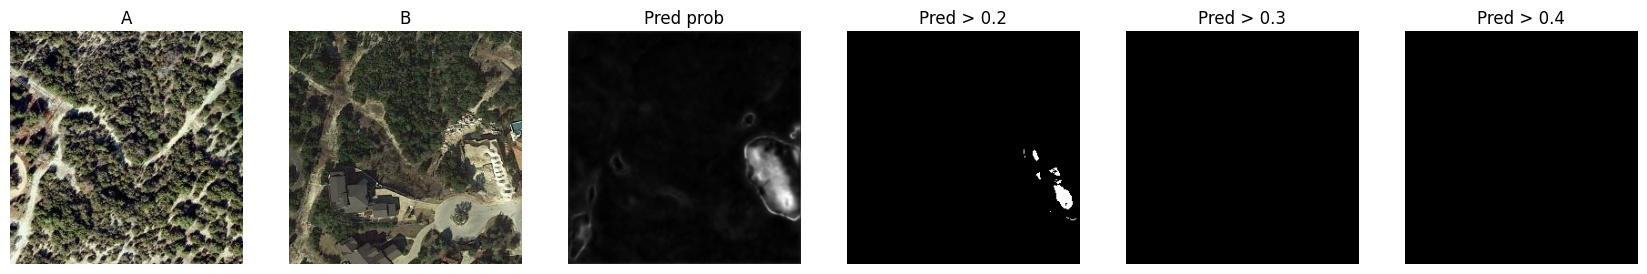

GT change ratio: 0.061737060546875
Pred prob stats: min/mean/max = 0.018243364989757538 0.0344209261238575 0.28482773900032043
GT unique: [0. 1.]


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def show_prob_and_thresholds(dataset, min_change_ratio=0.01, thresholds=(0.2, 0.3, 0.4)):
    for (A, B), M in dataset:
        ratio = tf.reduce_mean(M, axis=[1,2,3]).numpy()
        idxs = np.where(ratio >= min_change_ratio)[0]
        if len(idxs) == 0:
            continue

        i = idxs[0]
        PR = model.predict([A[i:i+1], B[i:i+1]], verbose=0)[0].squeeze()
        GT = M[i].numpy().squeeze()

        cols = 3 + len(thresholds)  # A, B, Pred prob, then thresholds
        plt.figure(figsize=(3.5*cols, 4))

        plt.subplot(1, cols, 1); plt.imshow(A[i].numpy()); plt.title("A"); plt.axis("off")
        plt.subplot(1, cols, 2); plt.imshow(B[i].numpy()); plt.title("B"); plt.axis("off")
        plt.subplot(1, cols, 3); plt.imshow(PR, cmap="gray"); plt.title("Pred prob"); plt.axis("off")

        for j, t in enumerate(thresholds):
            plt.subplot(1, cols, 4+j)
            plt.imshow(PR > t, cmap="gray")
            plt.title(f"Pred > {t}")
            plt.axis("off")

        plt.show()


        print("GT change ratio:", float(ratio[i]))
        print("Pred prob stats: min/mean/max =", float(PR.min()), float(PR.mean()), float(PR.max()))
        print("GT unique:", np.unique(GT)[:10])
        return

    print("No patch found with that min_change_ratio; lower it.")

show_prob_and_thresholds(val_ds, min_change_ratio=0.01, thresholds=(0.2, 0.3, 0.4))


In [24]:
import numpy as np
import tensorflow as tf

def batch_iou_np(y_true, y_pred_bin, eps=1e-7):
    inter = np.sum(y_true * y_pred_bin, axis=(1,2,3))
    union = np.sum(y_true + y_pred_bin, axis=(1,2,3)) - inter
    return (inter + eps) / (union + eps)

def find_best_threshold(dataset, thresholds=np.linspace(0.05, 0.5, 19), n_batches=30):
    best_t, best_iou = None, -1.0

    for t in thresholds:
        ious = []
        for (A, B), M in dataset.take(n_batches):
            P = model.predict([A, B], verbose=0)
            Pbin = (P > t).astype(np.float32)
            y_true = M.numpy().astype(np.float32)
            ious.append(batch_iou_np(y_true, Pbin).mean())

        avg_iou = float(np.mean(ious))
        print(f"t={t:.2f}  mean IoU={avg_iou:.4f}")
        if avg_iou > best_iou:
            best_iou = avg_iou
            best_t = float(t)

    print("\nBest threshold:", best_t, "Best mean IoU:", best_iou)
    return best_t

best_t = find_best_threshold(val_ds)


t=0.05  mean IoU=0.0522
t=0.08  mean IoU=0.4519
t=0.10  mean IoU=0.4003
t=0.12  mean IoU=0.3885
t=0.15  mean IoU=0.4150
t=0.17  mean IoU=0.4110
t=0.20  mean IoU=0.4068
t=0.23  mean IoU=0.4539
t=0.25  mean IoU=0.4572
t=0.28  mean IoU=0.4313
t=0.30  mean IoU=0.6307
t=0.33  mean IoU=0.5210
t=0.35  mean IoU=0.4611
t=0.38  mean IoU=0.4866
t=0.40  mean IoU=0.4298
t=0.42  mean IoU=0.5347
t=0.45  mean IoU=0.4494
t=0.48  mean IoU=0.4850
t=0.50  mean IoU=0.4973

Best threshold: 0.3 Best mean IoU: 0.6306607723236084


## Test set preparation and thresholded evaluation

The following cells rebuild the test dataset, apply the trained model, and evaluate the predicted
probability maps after converting them into binary masks with a chosen threshold.

In [25]:
test_ds = build_dataset("test", training=False)
print(test_ds)


<_PrefetchDataset element_spec=((TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None)), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>


In [26]:
import numpy as np

def evaluate_dataset(dataset, threshold):
    tp = fp = fn = 0.0
    inter = union = 0.0

    for (A, B), M in dataset:
        P = model.predict([A, B], verbose=0)
        Pbin = (P > threshold).astype(np.float32)
        y = M.numpy().astype(np.float32)

        inter += np.sum(y * Pbin)
        union += np.sum(y + Pbin) - np.sum(y * Pbin)

        tp += np.sum(y * Pbin)
        fp += np.sum((1 - y) * Pbin)
        fn += np.sum(y * (1 - Pbin))

    iou = (inter + 1e-7) / (union + 1e-7)
    f1  = (2*tp + 1e-7) / (2*tp + fp + fn + 1e-7)
    return float(iou), float(f1)

test_iou, test_f1 = evaluate_dataset(test_ds, best_t)

print("Test IoU:", test_iou)
print("Test F1 :", test_f1)


Test IoU: 0.08708368986845016
Test F1 : 0.16021524369716644


In [27]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

os.makedirs("qualitative_results", exist_ok=True)

def save_test_examples(dataset, threshold, n=6, min_change_ratio=0.01):
    saved = 0
    for (A, B), M in dataset:
        ratios = tf.reduce_mean(M, axis=[1,2,3]).numpy()
        idxs = np.where(ratios >= min_change_ratio)[0]

        for i in idxs:
            P = model.predict([A[i:i+1], B[i:i+1]], verbose=0)[0].squeeze()
            GT = M[i].numpy().squeeze()

            fig = plt.figure(figsize=(14,4))
            plt.subplot(1,4,1); plt.imshow(A[i].numpy()); plt.title("A"); plt.axis("off")
            plt.subplot(1,4,2); plt.imshow(B[i].numpy()); plt.title("B"); plt.axis("off")
            plt.subplot(1,4,3); plt.imshow(GT, cmap="gray"); plt.title("GT"); plt.axis("off")
            plt.subplot(1,4,4); plt.imshow(P > threshold, cmap="gray"); plt.title("Pred"); plt.axis("off")

            path = f"qualitative_results/example_{saved}.png"
            plt.savefig(path, dpi=200, bbox_inches="tight")
            plt.close(fig)

            saved += 1
            if saved >= n:
                return

save_test_examples(test_ds, best_t)
!ls qualitative_results


example_0.png  example_2.png  example_4.png
example_1.png  example_3.png  example_5.png
